# Ukrainian War Restoration Projects · End-to-End Binary Classification (Excel → ML)
Pipeline including:
  - Leakage-aware preprocessing
  - Robust repeated CV and calibrated probabilities
  - Exploratory data analysis (EDA)
  - Residual diagnostics
  - Fairness slices
  - Permutation importance
  - Adversarial train↔test drift check
  - Proper artifacts saved to ./artifacts

====================== Cell 1 — Imports, project layout, src/ on sys.path ======================

In [1]:
# Purpose
# -------
# - Import all libraries used across the notebook
# - Make the project portable by adding ./src to sys.path from any cwd
# - Set consistent plotting and display options

from __future__ import annotations

import inspect
import json
import platform
import sys
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [2]:
# Global display / plotting
warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120
pd.options.display.max_columns = 200
pd.options.display.width = 180

In [3]:
def find_src_dir(start: Path, max_up: int = 5) -> Path:
    """
    Walk upward from `start` to locate a 'src' directory.
    This keeps the notebook runnable from any nested path.

    Parameters
    ----------
    start : Path
        Starting directory (usually Path.cwd()).
    max_up : int
        How many levels to walk up at most.

    Returns
    -------
    Path
        The resolved path to ./src.

    Raises
    ------
    FileNotFoundError
        If the directory cannot be found within max_up levels.
    """
    cur = start.resolve()
    for _ in range(max_up):
        cand = cur / "src"
        if cand.exists():
            return cand
        if cur.parent == cur:
            break
        cur = cur.parent
    raise FileNotFoundError(f"Could not find 'src' directory starting from: {start}")

In [4]:
SRC_DIR = find_src_dir(Path.cwd())
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

In [5]:
print("Using src directory:", SRC_DIR)
print("[stage][done] imports/environment ready")

Using src directory: C:\Users\vksen\projects\dream-ml-project-main\src
[stage][done] imports/environment ready


====================== Cell 2 — Utilities, seed, directories, config ======================

In [6]:
# Purpose
# -------
# - Import project utilities
# - Set seed and directories
# - Define configuration for I/O, ML and feature schema in one place

from utils import (
    RareCategoryGrouper,
    adversarial_auc,
    choose_best_name,
    clean_and_merge_strict,
    cv_summary_for_models,
    eda_overview,
    holdout_metrics,
    load_xlsx,
    mirror_to_dir,
    plot_corr_heatmap,
    plot_curves,
    plot_numeric_histograms,
    plot_topk_categories,
    residual_diagnostics,
    save_artifacts,
    set_global_seed,
)

In [7]:
SEED = 42
set_global_seed(SEED)

In [8]:
PROJECT_ROOT = SRC_DIR.parent
DATA_DIR = PROJECT_ROOT / "data"
ARTIFACTS = PROJECT_ROOT / "artifacts"
DATA_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS.mkdir(parents=True, exist_ok=True)

In [9]:
cfg = {
    "files": {
        "extraction": ["Extraction.xlsx", "*Extraction*.xlsx"],
        "completeness": ["Project completeness.xlsx", "*Project*completeness*.xlsx"],
        "digital": ["Digital index.xlsx", "*Digital*index*.xlsx"],
        "iri": [
            "Codificated IRI + Transparency.xlsx",
            "*Codificated*IRI*Transparency*.xlsx",
        ],
    },
    "ml": {
        "test_size": 0.20,
        "random_state": SEED,
        "cv_n_splits": 5,
        "cv_n_repeats": 2,
        # Small dataset → avoid synthetic oversampling that can overfit
        "use_smote": False,
        # Small dataset → prefer Platt scaling over isotonic
        "calibrate": True,
        "calibration": "sigmoid",
        "rare_min_freq": 30,
    },
    "features": {
        "numeric": [
            "Forseen duration, months",
            "Overall estimated budget, ₴",
            "Committed funding, ₴",
            "Contract value, ₴",
            "Number of objects",
            "Number of contracting processes",
            "Number of contracts",
            "Number of investment objects requiring design documents",
            "Financial_Efficiency",
            "Financial coverage",
            "City Outlook",
            "Municipal Services Quality Index",
            "City Council Approval",
            "Entrepreneurial Opportunities",
            "Institutional Capacity",
            "Internet Development",
            "Administrative Services Center (ASC) Development",
            "Paperless Services",
            "Digital Education",
            "Openness",
            "E-Services",
            "Sectoral Digital Transformation",
            "Digital Index",
        ],
        "target_col": "Project status",
        "target_mapping": {"complete": 1, "unsuccessful": 0},
        "region_cols": {"digital": "Region Name", "iri": "Oblast"},
        "canonical_region": "Region",
    },
}

In [10]:
print("SMOTE:", cfg["ml"]["use_smote"], "| calibration:", cfg["ml"]["calibration"])
print("[utils][done] configuration and paths prepared")

SMOTE: False | calibration: sigmoid
[utils][done] configuration and paths prepared


====================== Cell 3 — Resolve inputs and load Excel files ======================

In [11]:
# Purpose
# -------
# - Resolve .xlsx inputs with wildcard fallback
# - Copy into ./data to keep the repo self-contained
# - Load to DataFrames

paths = {
    key: mirror_to_dir(patterns, DATA_DIR) for key, patterns in cfg["files"].items()
}

[SKIP] Already present: C:\Users\vksen\projects\dream-ml-project-main\data\Extraction.xlsx
[SKIP] Already present: C:\Users\vksen\projects\dream-ml-project-main\data\Project completeness.xlsx
[SKIP] Already present: C:\Users\vksen\projects\dream-ml-project-main\data\Digital index.xlsx
[SKIP] Already present: C:\Users\vksen\projects\dream-ml-project-main\data\Codificated IRI + Transparency.xlsx


In [12]:
# Load Excel files (requires openpyxl)
df_extraction = load_xlsx([paths["extraction"].name])
df_completeness = load_xlsx([paths["completeness"].name])
df_digital = load_xlsx([paths["digital"].name])
df_iri = load_xlsx([paths["iri"].name])

In [13]:
print(
    "Shapes:",
    df_extraction.shape,
    df_completeness.shape,
    df_digital.shape,
    df_iri.shape,
)
print("[stage][done] inputs mirrored and loaded")

Shapes: (15927, 48) (15927, 15) (24, 10) (76, 7)
[stage][done] inputs mirrored and loaded


====================== Cell 5 — Quick EDA on raw extraction ======================

In [14]:
# Purpose
# -------
# - High-level glance at the raw extraction table
# - Basic missingness and a few distributions

eda_overview(df_extraction, target_col=cfg["features"]["target_col"])

Shape: (15927, 48)

Dtypes:
 Project code                                object
Link to Portal                              object
Date                                datetime64[ns]
Project update date                 datetime64[ns]
Project title                               object
Project status                              object
Project nature                              object
Forseen duration, months                    object
Initiator type                              object
Project author                              object
Initiator                                   object
Management body type                        object
Management body                             object
Implementer                                 object
Balancer                                    object
Object title                                object
Number of objects                            int64
Sector                                      object
Subsector                                   object
CP

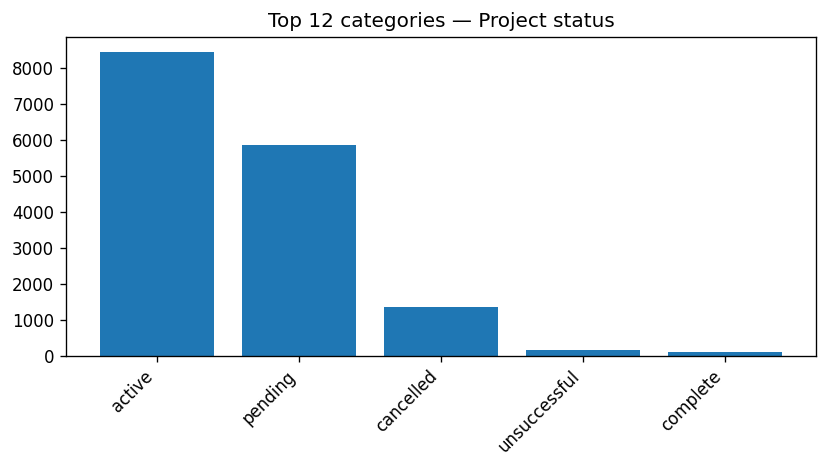

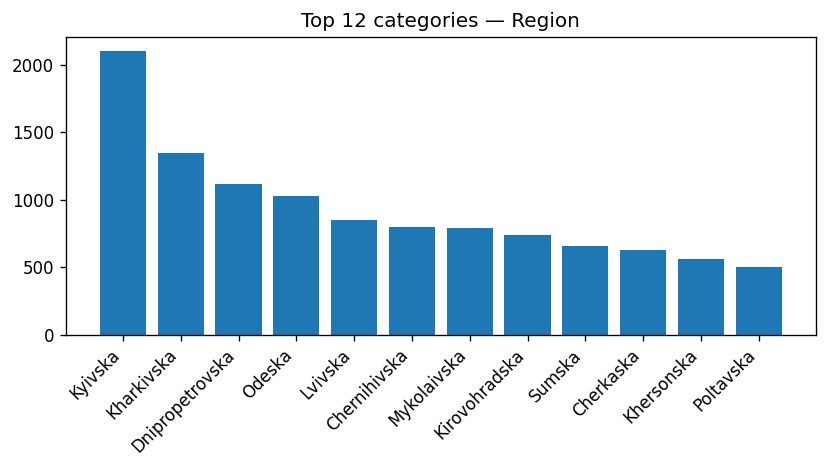

In [15]:
if cfg["features"]["target_col"] in df_extraction.columns:
    plot_topk_categories(df_extraction, col=cfg["features"]["target_col"])

if "Region" in df_extraction.columns:
    plot_topk_categories(df_extraction, col="Region")

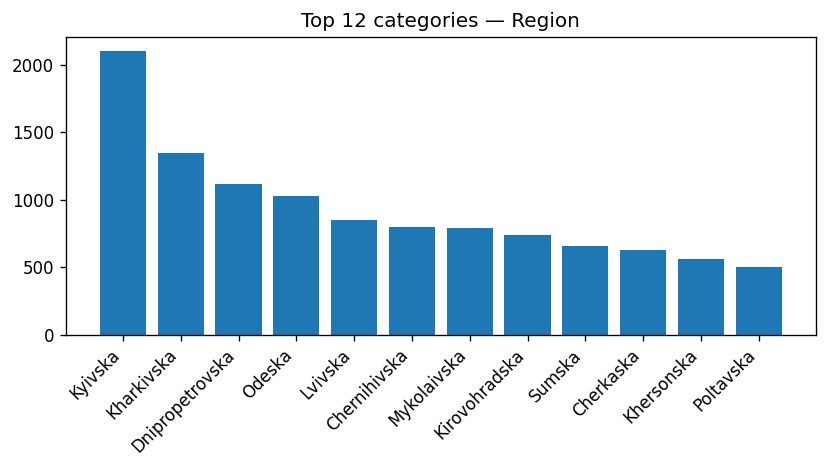

In [16]:
plot_topk_categories(df_extraction, col="Region")

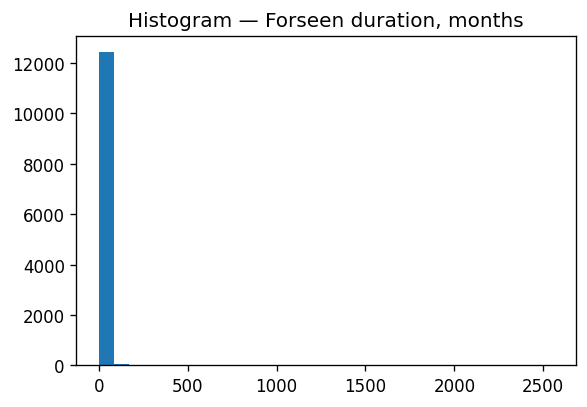

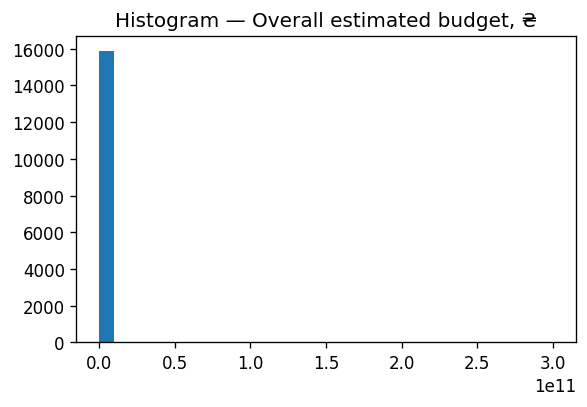

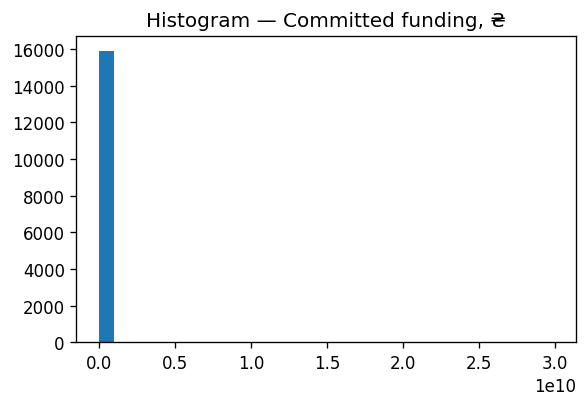

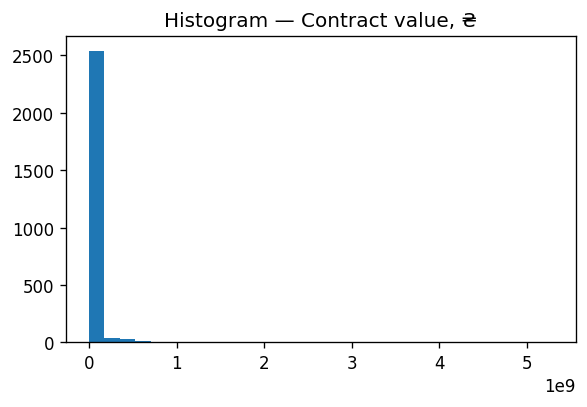

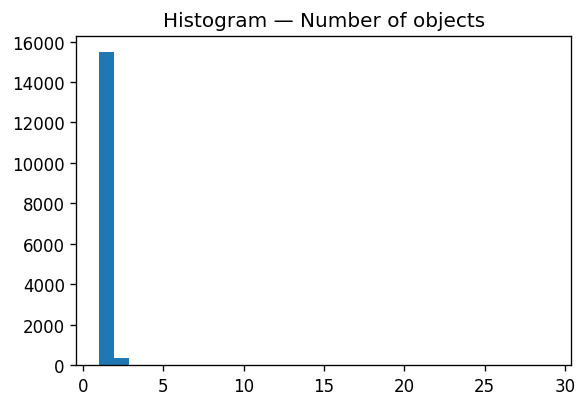

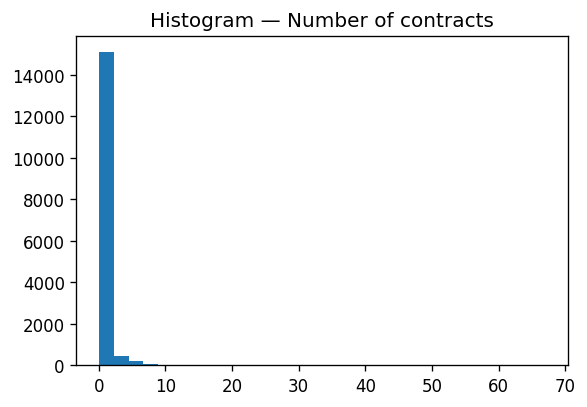

In [17]:
plot_numeric_histograms(
    df_extraction, numeric_cols=cfg["features"]["numeric"], bins=30, max_cols=6
)

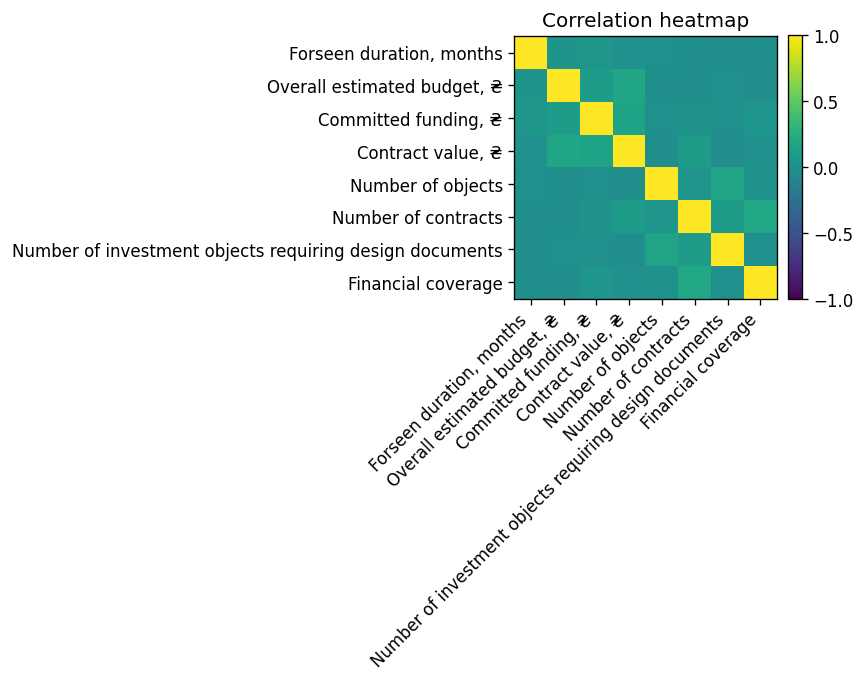

[stage][done] quick EDA on raw extraction


In [18]:
plot_corr_heatmap(df_extraction, numeric_cols=cfg["features"]["numeric"], max_cols=12)
print("[stage][done] quick EDA on raw extraction")

====================== Cell 5 — Domain cleaning and merging ======================

In [19]:
# Purpose
# -------
# - Domain-aware cleaning and enrichment of the four Excel inputs
# - Harmonize Region naming, sanitize numerics, merge indices, compute Financial_Efficiency

df_full = clean_and_merge_strict(
    df_ext=df_extraction,
    df_comp=df_completeness,
    df_dig=df_digital,
    df_iri=df_iri,
    cfg=cfg,
)

In [20]:
print("Merged shape:", df_full.shape)
display(df_full.head(3))
print("[enrich][done] cleaned and merged")

Merged shape: (15927, 48)


,Project code,Date,Project status,Project nature,"Forseen duration, months",Initiator type,Management body type,Number of objects,Sector,Subsector,Region,District,Locality type,Locality,"Overall estimated budget, ₴","Committed funding, ₴",Financial coverage,Number of tenders,Number of contracts,"Contract value, ₴",Funding form,Type of assistance,Number of investment objects requiring design documents,Number of design documents,Number of approved design documents,MultipleRegions,Project data availability,Metrics,Targets,Requirements,Documents,Images,Approaches,Items,Budgeting,Finance,Additional classifications,Contracting processes,Institutional Capacity,Internet Development,Administrative Services Center (ASC) Development,Paperless Services,Digital Education,Openness,E-Services,Sectoral Digital Transformation,Digital Index,Financial_Efficiency
0,241123-A737DC9B,2023-11-24,cancelled,Rehabilitation,NaN,nan,Central Body,1.0,"Industry, Trade and Services",Housing Construction,Sumska,Okhtyrskyi,city,Trostianets,2.990642e+10,2.990642e+10,1,1,1.0,17450164.72,nan,nan,1.0,0,0,False,1.000000,Available,Available,Available,Available,Available,Available,Available,Available,Available,Available,Available,0.3,0.173,0.066,0.182,0.398,0.1,0.216,0.104,0.435,1.0
1,091024-88B407AF,2024-10-09,active,New construction,360.0,nan,Central Body,1.0,Energy and Extractives,Non-Renewable Energy Generation,nan,nan,nan,nan,1.574141e+10,1.574141e+10,1,0,0.0,NaN,loan,financial support,0.0,0,0,False,0.818182,Available,Not available,Available,Available,Available,Available,Available,Available,Available,Available,Not available,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
2,021024-0B8CCA14,2024-10-02,active,New construction,24.0,Central Body,Central Body,1.0,Energy and Extractives,Non-Renewable Energy Generation,nan,nan,nan,nan,1.334155e+10,1.334155e+10,1,0,0.0,NaN,"grant, loan",financial support,0.0,0,0,False,0.909091,Available,Available,Available,Available,Available,Available,Available,Available,Available,Available,Not available,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


[enrich][done] cleaned and merged


====================== Cell 6 — Supervised setup: filter label, build X and y, basic hygiene ======================

In [21]:
# Purpose
# -------
# - Keep only labeled rows
# - Build X, y
# - Robust type hygiene for numeric and categorical columns
# - Train / test split with stratification

mask = df_full[cfg["features"]["target_col"]].isin(
    cfg["features"]["target_mapping"].keys()
)
df_f = df_full.loc[mask].copy()

In [22]:
# Binary target
df_f["Project_Outcome"] = (
    df_f[cfg["features"]["target_col"]]
    .map(cfg["features"]["target_mapping"])
    .astype(int)
)

In [23]:
# Feature matrix and target vector
X = df_f.drop(
    columns=["Project code", cfg["features"]["target_col"], "Date", "Project_Outcome"],
    errors="ignore",
)
y = df_f["Project_Outcome"].astype(int)

In [24]:
# Split numeric / categorical lists from config, keep only those present
numeric = [c for c in cfg["features"]["numeric"] if c in X.columns]
categorical = [c for c in X.columns if c not in numeric and X[c].dtype == "object"]

In [25]:
# Numeric hygiene
for c in numeric:
    X[c] = pd.to_numeric(X[c], errors="coerce").replace([np.inf, -np.inf], np.nan)

In [26]:
# Categorical hygiene (fill missing BEFORE converting to string)
for c in categorical:
    X[c] = X[c].where(X[c].notna(), "Unknown").astype(str)

In [27]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=cfg["ml"]["test_size"],
    stratify=y,
    random_state=cfg["ml"]["random_state"],
)
print(
    "Train shape:",
    X_train.shape,
    "Test shape:",
    X_test.shape,
    "Class1 rate:",
    float(y_train.mean()),
)
print("[stage][done] supervised frame ready")

Train shape: (208, 45) Test shape: (52, 45) Class1 rate: 0.3942307692307692
[stage][done] supervised frame ready


====================== Cell 7 — Structural EDA (numeric summary, cardinality, missingness, boxplots) ======================

In [28]:
# Purpose
# -------
# - Structural EDA patterned after your other project
# - Numeric summaries, categorical cardinality, missingness report
# - Boxplots by selected factors
# - Target-by-group summaries for key dimensions


def numeric_summary(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    """
    Robust numeric summary with percentiles and missingness.
    """
    present = [c for c in cols if c in df.columns]
    if not present:
        return pd.DataFrame(
            columns=[
                "count",
                "mean",
                "std",
                "min",
                "1%",
                "5%",
                "25%",
                "50%",
                "75%",
                "95%",
                "99%",
                "max",
                "missing_pct",
            ]
        )
    s = {}
    for c in present:
        x = pd.to_numeric(df[c], errors="coerce")
        s[c] = {
            "count": float(x.notna().sum()),
            "mean": float(x.mean()),
            "std": float(x.std()),
            "min": float(x.min()),
            "1%": float(x.quantile(0.01)),
            "5%": float(x.quantile(0.05)),
            "25%": float(x.quantile(0.25)),
            "50%": float(x.quantile(0.50)),
            "75%": float(x.quantile(0.75)),
            "95%": float(x.quantile(0.95)),
            "99%": float(x.quantile(0.99)),
            "max": float(x.max()),
            "missing_pct": float(100 * x.isna().mean()),
        }
    return pd.DataFrame(s).T

In [29]:
def cat_cardinality(df: pd.DataFrame, cols: list[str], top: int = 10) -> pd.DataFrame:
    """
    Cardinality report for selected categoricals.
    """
    rows = []
    for c in cols:
        if c in df.columns:
            rows.append(
                {
                    "column": c,
                    "cardinality": int(df[c].astype(str).nunique(dropna=False)),
                }
            )
    out = pd.DataFrame(rows).sort_values("cardinality", ascending=False)
    return out.head(top)

In [30]:
def na_report(df: pd.DataFrame, top_k: int = 30) -> pd.DataFrame:
    """
    Top-k columns by NA percentage.
    """
    na = df.isna().mean().sort_values(ascending=False)
    return (
        na.head(top_k)
        .mul(100)
        .rename("na_pct")
        .to_frame()
        .reset_index()
        .rename(columns={"index": "column"})
    )

In [31]:
def target_by_group(df: pd.DataFrame, target_col: str, group_col: str) -> pd.DataFrame:
    """
    Count and mean target by group for quick fairness / subgroup scans.
    """
    if target_col not in df.columns or group_col not in df.columns:
        return pd.DataFrame(columns=[group_col, "count", "mean"])
    g = (
        df.groupby(group_col)[target_col]
        .agg(["count", "mean"])
        .rename(columns={"mean": "positive_rate"})
        .sort_values("count", ascending=False)
        .reset_index()
    )
    return g

In [32]:
def safe_sample(
    df: pd.DataFrame, n: int = 2000, random_state: int = 42
) -> pd.DataFrame:
    """
    Small sample for faster plotting.
    """
    if len(df) <= n:
        return df.copy()
    return df.sample(n=n, random_state=random_state)

In [33]:
# 1) Basic structure
print("Shape (labeled frame):", df_f.shape)
if "Date" in df_f.columns:
    years = pd.to_datetime(df_f["Date"], errors="coerce").dt.year
    print("Years:", sorted(years.dropna().unique().tolist()))
    print("Rows by year:\n", years.value_counts().sort_index())

Shape (labeled frame): (260, 49)
Years: [2023, 2024, 2025]
Rows by year:
 Date
2023     89
2024    132
2025     39
Name: count, dtype: int64


In [34]:
# 2) Cardinality snapshot
cat_cols_for_card = [
    c
    for c in [
        "Region",
        "Project nature",
        "Initiator type",
        "Management body type",
        "Sector",
    ]
    if c in df_f.columns
]
display(cat_cardinality(df_f, cols=cat_cols_for_card, top=10))

,column,cardinality
0,Region,25
4,Sector,10
3,Management body type,6
2,Initiator type,4
1,Project nature,3


In [35]:
# 3) Missingness
display(na_report(df_f, top_k=25))

,column,na_pct
0,"Contract value, ₴",54.615385
1,"Forseen duration, months",37.307692
2,Financial_Efficiency,25.769231
3,Digital Education,0.384615
4,Sectoral Digital Transformation,0.384615
5,Paperless Services,0.384615
6,Internet Development,0.384615
7,Institutional Capacity,0.384615
8,Administrative Services Center (ASC) Development,0.384615
9,Digital Index,0.384615


In [36]:
# 4) Numeric summary
num_cols_for_summary = [
    c
    for c in [
        "Contract value, ₴",
        "Overall estimated budget, ₴",
        "Committed funding, ₴",
        "Number of contracts",
        "Number of contracting processes",
        "Financial_Efficiency",
        "Forseen duration, months",
        "Financial coverage",
    ]
    if c in df_f.columns
]
display(numeric_summary(df_f, cols=num_cols_for_summary))

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing_pct
"Contract value, ₴",118.0,2.548759e+07,7.197693e+07,49840.0,77700.0,132694.8,1.001788e+06,3.896053e+06,1.054737e+07,1.117356e+08,3.821588e+08,3.869495e+08,54.615385
"Overall estimated budget, ₴",260.0,1.115319e+08,1.283997e+09,0.0,0.0,0.0,0.000000e+00,3.357060e+06,2.303165e+07,1.857209e+08,4.327485e+08,2.070000e+10,0.000000
"Committed funding, ₴",260.0,3.914690e+07,2.901087e+08,0.0,0.0,0.0,0.000000e+00,1.091972e+06,1.018278e+07,1.152561e+08,3.455565e+08,4.600000e+09,0.000000
Number of contracts,260.0,1.250000e+00,2.432684e+00,0.0,0.0,0.0,0.000000e+00,0.000000e+00,1.000000e+00,6.000000e+00,1.341000e+01,1.700000e+01,0.000000
Financial_Efficiency,193.0,8.743166e-01,2.169917e+00,0.0,0.0,0.0,3.629194e-01,9.999868e-01,1.000000e+00,1.000000e+00,1.125915e+00,3.032040e+01,25.769231
"Forseen duration, months",163.0,2.264417e+01,1.585784e+02,1.0,1.0,1.1,4.000000e+00,7.000000e+00,1.200000e+01,2.400000e+01,1.328800e+02,2.024000e+03,37.307692
Financial coverage,193.0,8.740829e-01,2.169905e+00,0.0,0.0,0.0,3.620000e-01,9.990000e-01,1.000000e+00,1.000000e+00,1.125840e+00,3.032000e+01,25.769231


In [37]:
# 5) Target by key parameters
df_f_small = df_f[
    [
        "Project_Outcome",
        "Region",
        "Project nature",
        "Initiator type",
        "Management body type",
    ]
].copy()
for col in [c for c in df_f_small.columns if c != "Project_Outcome"]:
    if col in df_f_small.columns:
        print(f"\nTarget by {col}:")
        display(target_by_group(df_f_small, "Project_Outcome", col).head(12))


Target by Region:


,Region,count,positive_rate
0,Mykolaivska,31,0.258065
1,Kyivska,22,0.409091
2,Sumska,18,0.111111
3,Dnipropetrovska,18,0.666667
4,Chernihivska,18,0.444444
5,Khersonska,16,0.562500
6,Lvivska,15,0.266667
7,Volynska,15,0.800000
8,Kharkivska,13,0.384615
9,Poltavska,13,0.230769



Target by Project nature:


,Project nature,count,positive_rate
0,Rehabilitation,181,0.348066
1,New construction,40,0.225000
2,Equipment,39,0.769231



Target by Initiator type:


,Initiator type,count,positive_rate
0,nan,156,0.301282
1,Local Body,100,0.550000
2,Administration,3,0.000000
3,"Administration, Local Body",1,0.000000



Target by Management body type:


,Management body type,count,positive_rate
0,Local Body,163,0.539877
1,nan,34,0.029412
2,Administration,30,0.100000
3,Central Body,25,0.400000
4,"Central Body, Local Body",5,0.000000
5,"Administration, Local Body",3,0.000000


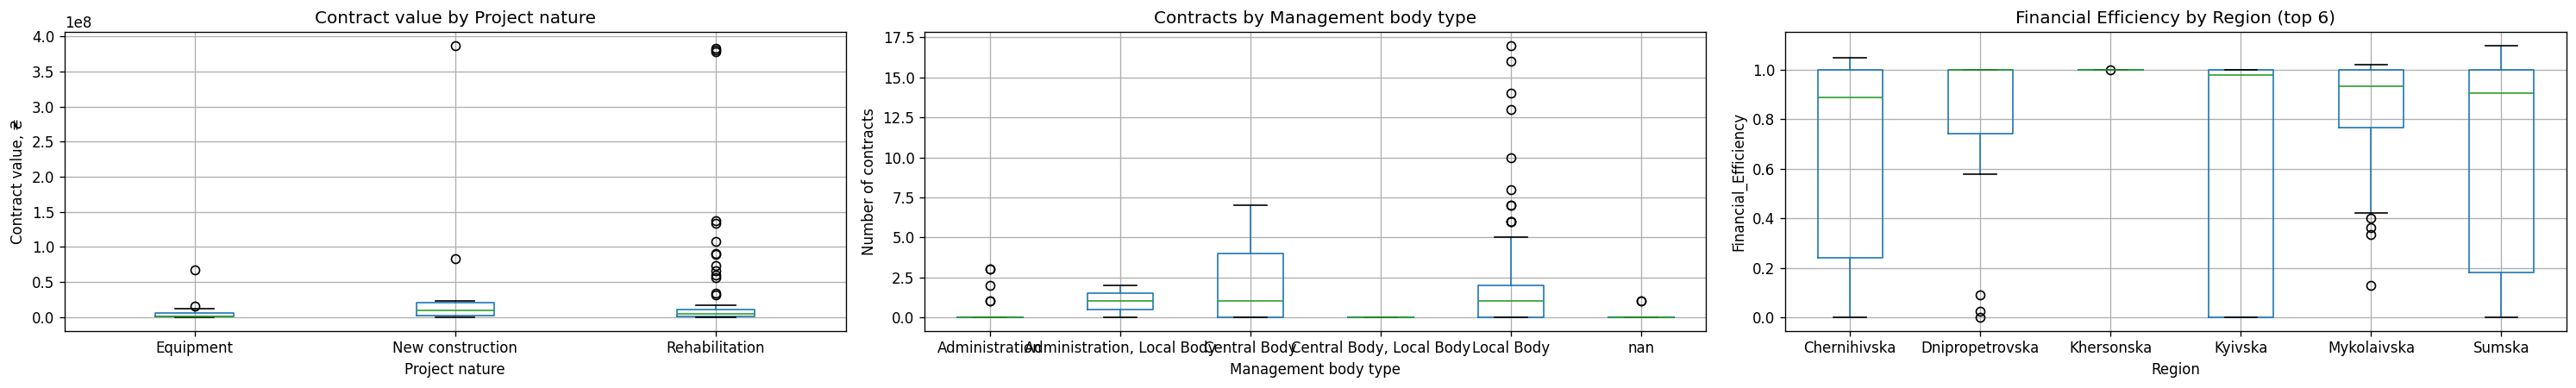

In [38]:
# 6) Boxplots (sampled for speed)
S = safe_sample(df_f, n=2000, random_state=SEED)
fig, axes = plt.subplots(1, 3, figsize=(25, 4))

# Contract value by Project nature
if {"Contract value, ₴", "Project nature"}.issubset(S.columns):
    S.boxplot(column="Contract value, ₴", by="Project nature", ax=axes[0])
    axes[0].set_title("Contract value by Project nature")
    axes[0].set_xlabel("Project nature")
    axes[0].set_ylabel("Contract value, ₴")
    axes[0].figure.suptitle("")
else:
    axes[0].set_visible(False)

# Number of contracts by Management body type
if {"Number of contracts", "Management body type"}.issubset(S.columns):
    S.boxplot(column="Number of contracts", by="Management body type", ax=axes[1])
    axes[1].set_title("Contracts by Management body type")
    axes[1].set_xlabel("Management body type")
    axes[1].set_ylabel("Number of contracts")
    axes[1].figure.suptitle("")
else:
    axes[1].set_visible(False)

# Financial Efficiency by Region (top 6 regions by volume)
if {"Financial_Efficiency", "Region"}.issubset(S.columns):
    top_regs = S["Region"].value_counts().head(6).index
    S2 = S[S["Region"].isin(top_regs)]
    S2.boxplot(column="Financial_Efficiency", by="Region", ax=axes[2])
    axes[2].set_title("Financial Efficiency by Region (top 6)")
    axes[2].set_xlabel("Region")
    axes[2].set_ylabel("Financial_Efficiency")
    axes[2].figure.suptitle("")
else:
    axes[2].set_visible(False)

plt.tight_layout()
plt.show()

In [39]:
print("[enrich][done] structural EDA complete")

[enrich][done] structural EDA complete


====================== Cell 8 — Preprocessing and candidate models ======================

In [40]:
# Purpose
# -------
# - Two preprocessors:
#     * scaled numerics for linear models
#     * unscaled numerics for trees (tree-friendly; no StandardScaler)
# - Consistent rare-category grouping before OHE
# - Probability calibration for all models (including XGB if available)


def _ohe_kwargs() -> dict:
    """
    Version-robust kwargs for OneHotEncoder across sklearn versions.
    """
    enc_sig = inspect.signature(OneHotEncoder.__init__)
    return (
        dict(handle_unknown="ignore", sparse_output=False)
        if "sparse_output" in enc_sig.parameters
        else dict(handle_unknown="ignore", sparse=False)
    )

In [41]:
def build_preprocessor_scaled(
    numeric_cols, categorical_cols, rare_min_freq=30
) -> ColumnTransformer:
    """
    Preprocessor with scaling for numerics — appropriate for linear models.
    Rare categories are grouped before OHE to control cardinality.
    """
    num = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    cat = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("rare", RareCategoryGrouper(min_freq=rare_min_freq)),
            ("onehot", OneHotEncoder(**_ohe_kwargs())),
        ]
    )
    return ColumnTransformer(
        [("num", num, numeric_cols), ("cat", cat, categorical_cols)],
        remainder="drop",
        verbose_feature_names_out=False,
    )

In [42]:
def build_preprocessor_unscaled(
    numeric_cols, categorical_cols, rare_min_freq=30
) -> ColumnTransformer:
    """
    Preprocessor without scaling for numerics — preferred for tree-based models.
    """
    num = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
        ]
    )
    cat = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("rare", RareCategoryGrouper(min_freq=rare_min_freq)),
            ("onehot", OneHotEncoder(**_ohe_kwargs())),
        ]
    )
    return ColumnTransformer(
        [("num", num, numeric_cols), ("cat", cat, categorical_cols)],
        remainder="drop",
        verbose_feature_names_out=False,
    )

In [43]:
# Build preprocessors
preproc_logreg = build_preprocessor_scaled(
    numeric, categorical, rare_min_freq=cfg["ml"]["rare_min_freq"]
)
preproc_tree = build_preprocessor_unscaled(
    numeric, categorical, rare_min_freq=cfg["ml"]["rare_min_freq"]
)

In [44]:
def _calibrated(estimator, method: str = "sigmoid", cv: int = 3):
    """
    Wrap an estimator into CalibratedClassifierCV in a version-safe way.
    Prefer 'sigmoid' (Platt scaling) on small data for stability.
    """
    sig = inspect.signature(CalibratedClassifierCV.__init__)
    kwargs = {"method": method, "cv": cv}
    if "estimator" in sig.parameters:
        kwargs["estimator"] = estimator
    else:
        kwargs["base_estimator"] = estimator
    return CalibratedClassifierCV(**kwargs)

In [45]:
# Assemble models
models = {
    "LogReg": Pipeline(
        [
            ("preprocessor", preproc_logreg),
            (
                "model",
                _calibrated(
                    LogisticRegression(
                        C=1.5, max_iter=800, class_weight="balanced", solver="lbfgs"
                    ),
                    method=cfg["ml"]["calibration"],
                    cv=3,
                ),
            ),
        ]
    ),
    "RF": Pipeline(
        [
            ("preprocessor", preproc_tree),
            (
                "model",
                _calibrated(
                    RandomForestClassifier(
                        n_estimators=400,
                        max_depth=None,
                        min_samples_split=5,
                        n_jobs=-1,
                        class_weight="balanced_subsample",
                        random_state=SEED,
                    ),
                    method=cfg["ml"]["calibration"],
                    cv=3,
                ),
            ),
        ]
    ),
    "GB": Pipeline(
        [
            ("preprocessor", preproc_tree),
            (
                "model",
                _calibrated(
                    GradientBoostingClassifier(random_state=SEED),
                    method=cfg["ml"]["calibration"],
                    cv=3,
                ),
            ),
        ]
    ),
}

In [46]:
try:
    models["XGB"] = Pipeline(
        [
            ("preprocessor", preproc_tree),
            (
                "model",
                _calibrated(
                    xgb.XGBClassifier(
                        n_estimators=600,
                        max_depth=5,
                        learning_rate=0.05,
                        subsample=0.8,
                        colsample_bytree=0.8,
                        reg_lambda=1.0,
                        tree_method="hist",
                        n_jobs=-1,
                        random_state=SEED,
                        eval_metric="logloss",
                    ),
                    method=cfg["ml"]["calibration"],
                    cv=3,
                ),
            ),
        ]
    )
except Exception:
    pass

In [47]:
print("Models:", list(models.keys()))
print("[model][done] preprocessors and candidates ready")

Models: ['LogReg', 'RF', 'GB', 'XGB']
[model][done] preprocessors and candidates ready


====================== Cell 10 — Repeated CV, model selection, training best ======================

In [48]:
# Purpose
# -------
# - Repeated stratified CV across candidates
# - Select best by PR-AUC (then ROC-AUC)
# - Fit the winner on the training split

cv_df = cv_summary_for_models(
    models=models,
    X=X_train,
    y=y_train,
    n_splits=cfg["ml"]["cv_n_splits"],
    n_repeats=cfg["ml"]["cv_n_repeats"],
    seed=cfg["ml"]["random_state"],
)
display(cv_df)

,model,roc_auc_mean,roc_auc_lo,roc_auc_hi,pr_auc_mean,pr_auc_lo,pr_auc_hi,f1_mean,f1_lo,f1_hi,brier_mean
0,RF,0.993794,0.972783,1.000000,0.991049,0.959667,1.000000,0.938221,0.852632,0.993182,0.038208
1,XGB,0.989391,0.964636,1.000000,0.983595,0.950102,1.000000,0.935476,0.820000,0.993571,0.036277
2,GB,0.984774,0.952430,1.000000,0.975722,0.916259,1.000000,0.951180,0.888889,1.000000,0.039921
3,LogReg,0.971485,0.924585,0.998412,0.938255,0.789296,0.997828,0.904376,0.736533,0.961765,0.068375


In [49]:
best_name = choose_best_name(cv_df)
print("Best by PR-AUC then ROC-AUC:", best_name)

Best by PR-AUC then ROC-AUC: RF


In [50]:
best_pipe = models[best_name]
best_pipe.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [51]:
print("[best]", best_name, "— fitted on train")

[best] RF — fitted on train


====================== Cell 10 — Holdout metrics, curves, confusion matrix ======================

In [52]:
# Purpose
# -------
# - Evaluate the best pipeline on holdout
# - Curves: ROC, PR, Calibration
# - Confusion matrix at threshold 0.5

y_prob = best_pipe.predict_proba(X_test)[:, 1]
y_true = y_test.to_numpy()
y_pred = (y_prob >= 0.5).astype(int)

In [53]:
metrics = holdout_metrics(y_true, y_prob, threshold=0.5)
print(metrics)

{'roc_auc': 0.996875, 'pr_auc': 0.9951190476190477, 'brier': 0.02670844723458908, 'accuracy': 0.9615384615384616, 'precision': 0.9090909090909091, 'recall': 1.0, 'f1': 0.9523809523809523}


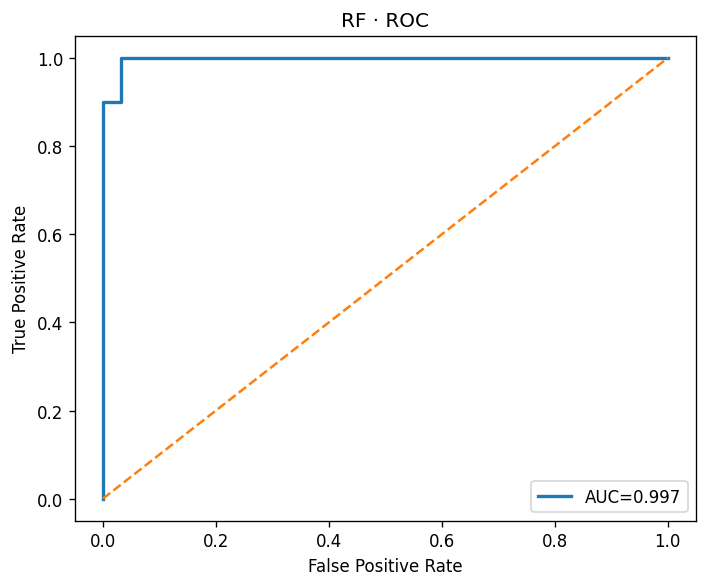

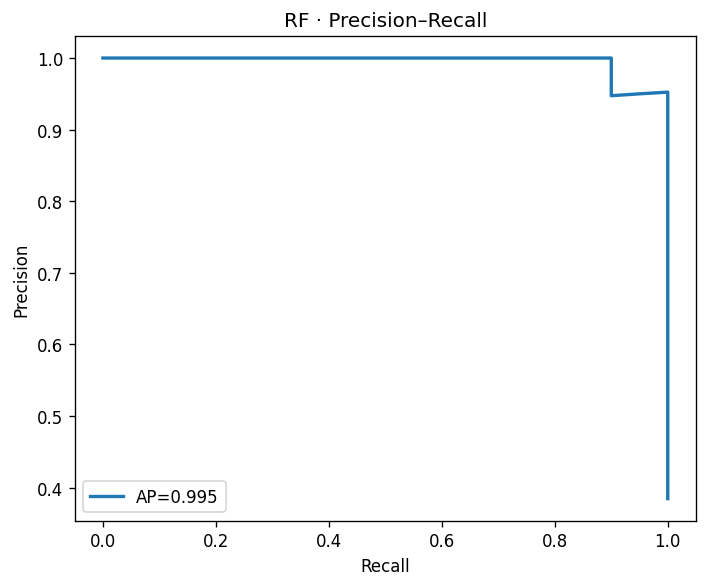

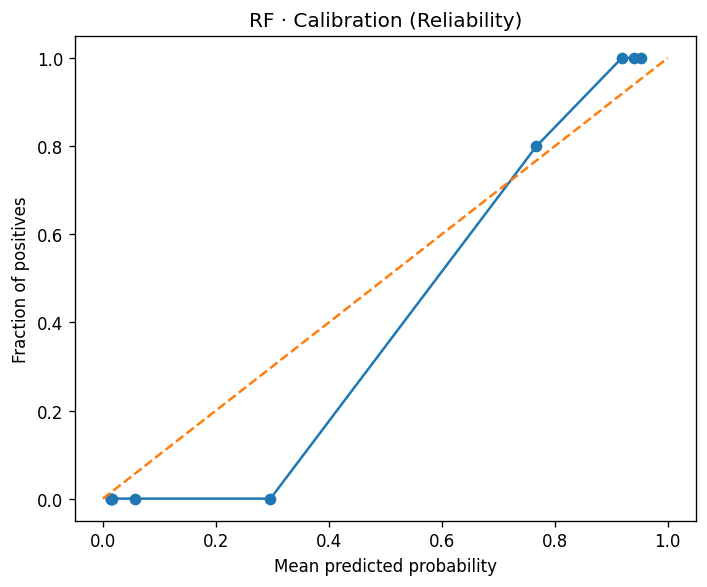

In [54]:
plot_curves(y_true, y_prob, title_prefix=f"{best_name} · ")

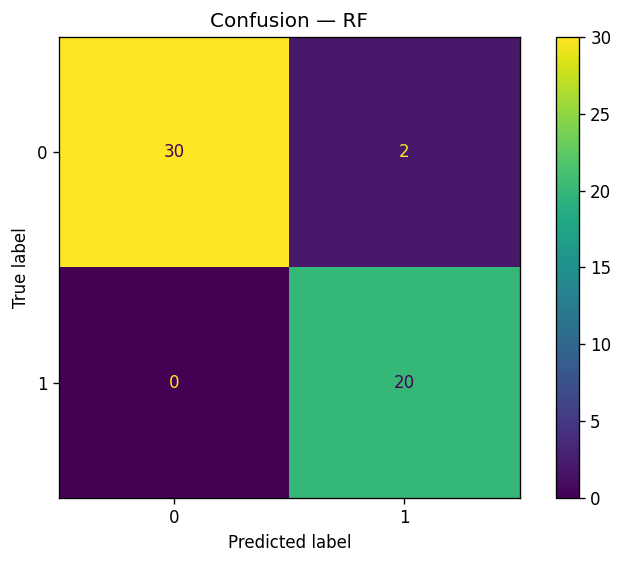

In [55]:
ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
plt.title(f"Confusion — {best_name}")
plt.tight_layout()
plt.show()

In [56]:
print("[stage][done] holdout metrics and plots")

[stage][done] holdout metrics and plots


====================== Cell 11 — Residual diagnostics (classification residuals) ======================

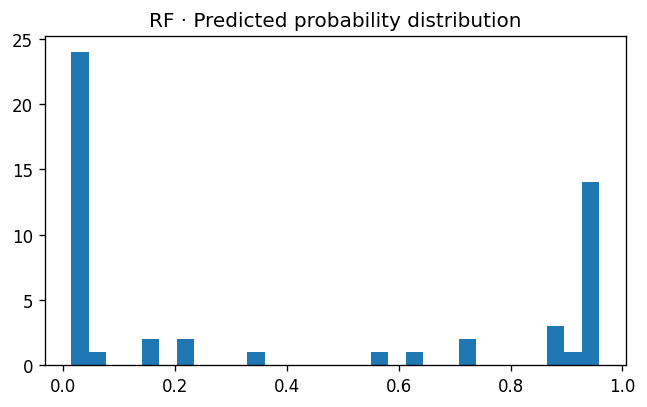

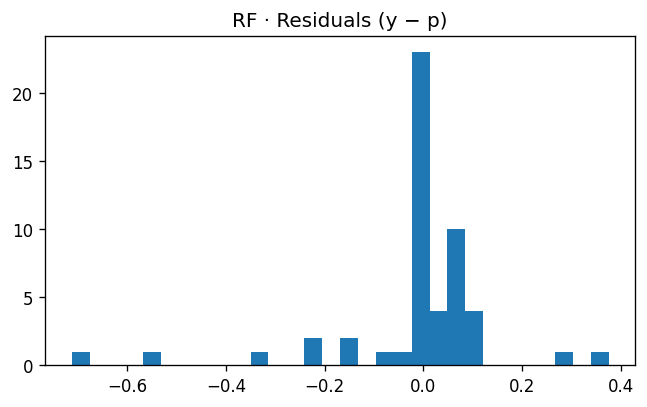

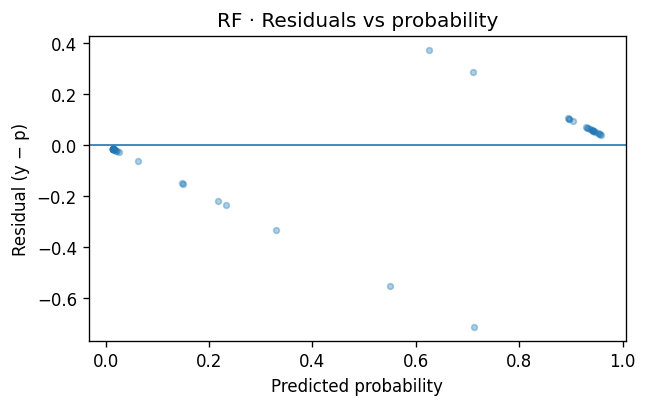

[stage][done] residual diagnostics


In [57]:
# Purpose
# -------
# - Diagnostics for probabilistic residuals: distributions and scatter
# - Quick summary stats for logging

resid_info = residual_diagnostics(
    y_true=y_true,
    y_prob=y_prob,
    title_prefix=f"{best_name} · ",
    show_examples=False,  # keep False in public repos to avoid accidental exposure
    X_test=None,
)
resid_info
print("[stage][done] residual diagnostics")

====================== Cell 12 — Permutation importance ======================

In [58]:
# Purpose
# -------
# - Compute permutation importance on the ORIGINAL input columns for readable names
# - Aggregate across several seeds to stabilize rankings on small test sets
# - Use AP (average precision) scoring to align with PR-AUC selection


def stable_permutation_importance(
    pipeline: Pipeline,
    X: pd.DataFrame,
    y: pd.Series | np.ndarray,
    seeds=(42, 1337, 7, 19, 2025),
    n_repeats: int = 10,
    top_k: int = 25,
    scoring: str = "average_precision",
) -> pd.DataFrame:
    """
    Bootstrap-averaged permutation importance on the ORIGINAL input space.

    Parameters
    ----------
    pipeline : fitted Pipeline
        The trained pipeline to evaluate.
    X, y : pd.DataFrame, array-like
        Holdout features and labels. X must be a DataFrame to supply readable names.
    seeds : iterable of int
        Seeds for repeated permutation runs to smooth variance on small sets.
    n_repeats : int
        Repeats per seed.
    top_k : int
        Number of features to show.
    scoring : str
        Metric to optimize; 'average_precision' pairs with PR-AUC selection.

    Returns
    -------
    pd.DataFrame with columns ['feature', 'importance'] sorted by importance.
    """
    feat_names = (
        X.columns.to_numpy()
        if hasattr(X, "columns")
        else np.array([f"feature_{i}" for i in range(X.shape[1])])
    )

    frames = []
    for s in seeds:
        perm = permutation_importance(
            pipeline,
            X,
            y,
            n_repeats=n_repeats,
            random_state=s,
            n_jobs=-1,
            scoring=scoring,
        )
        frames.append(
            pd.DataFrame({"feature": feat_names, f"imp_{s}": perm.importances_mean})
        )

    imp = frames[0]
    for df_ in frames[1:]:
        imp = imp.merge(df_, on="feature", how="outer")
    imp = imp.fillna(0.0)

    seed_cols = [c for c in imp.columns if c.startswith("imp_")]
    imp["importance"] = imp[seed_cols].mean(axis=1)

    return (
        imp[["feature", "importance"]]
        .sort_values("importance", ascending=False)
        .head(top_k)
        .reset_index(drop=True)
    )

In [59]:
imp_df = stable_permutation_importance(
    pipeline=best_pipe,
    X=X_test,
    y=y_test,
    seeds=(42, 1337, 7, 19, 2025),
    n_repeats=10,
    top_k=25,
    scoring="average_precision",
)
display(imp_df)
print("[stage][done] permutation importance")

,feature,importance
0,Number of contracts,0.096955
1,Contracting processes,0.027311
2,Financial coverage,0.011003
3,Items,0.007718
4,Financial_Efficiency,0.004823
5,Finance,0.004067
6,Additional classifications,0.001239
7,Management body type,0.001126
8,Images,0.000605
9,"Contract value, ₴",0.000191


[stage][done] permutation importance


====================== Cell 13 — Fairness slices by group ======================

In [60]:
# Purpose
# -------
# - Group fairness slices with minimum support guards
# - Skips groups with insufficient positives/negatives to avoid noisy estimates
# - Only slice by columns that actually exist (no 'sex' reference here)


def slice_binary_metrics_sane(
    X: pd.DataFrame,
    y_true: np.ndarray,
    y_prob: np.ndarray,
    *,
    col: str,
    threshold: float = 0.5,
    min_n: int = 10,
    min_pos: int = 3,
    min_neg: int = 3,
) -> pd.DataFrame:
    """
    Compute group slice metrics with minimum support guards.

    Returns a DataFrame with columns:
    [col, n, pos, neg, positive_rate, tpr, fpr, roc_auc].
    Returns an empty frame with these columns if nothing passes filters.
    """
    required_cols = [col, "n", "pos", "neg", "positive_rate", "tpr", "fpr", "roc_auc"]
    if col not in X.columns:
        return pd.DataFrame(columns=required_cols)

    # Ensure positional alignment between X and targets
    X_local = X.reset_index(drop=True)
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob, dtype=float)
    y_pred = (y_prob >= threshold).astype(int)

    rows = []
    for g, idx in X_local.groupby(col).groups.items():
        idx = np.fromiter(idx, dtype=int)
        n = idx.size
        if n < min_n:
            continue

        yt = y_true[idx]
        yp = y_pred[idx]
        pr = y_prob[idx]

        n_pos = int((yt == 1).sum())
        n_neg = int((yt == 0).sum())
        if n_pos < min_pos or n_neg < min_neg:
            continue

        pos_rate = float(yp.mean())
        tpr = float(((yt == 1) & (yp == 1)).sum() / n_pos) if n_pos > 0 else np.nan
        fpr = float(((yt == 0) & (yp == 1)).sum() / n_neg) if n_neg > 0 else np.nan
        roc = np.nan if len(np.unique(yt)) < 2 else float(roc_auc_score(yt, pr))

        rows.append(
            {
                col: g,
                "n": int(n),
                "pos": n_pos,
                "neg": n_neg,
                "positive_rate": pos_rate,
                "tpr": tpr,
                "fpr": fpr,
                "roc_auc": roc,
            }
        )

    df = pd.DataFrame(rows, columns=required_cols)
    if df.empty:
        return df
    return df.sort_values(["n", "pos", "neg"], ascending=False).reset_index(drop=True)

In [61]:
def disparity(df: pd.DataFrame, metric: str) -> float:
    """
    Simple disparity as max - min for a given metric column.
    Returns NaN if the metric column is missing or df is empty.
    """
    if df.empty or metric not in df.columns:
        return float("nan")
    return float(df[metric].max() - df[metric].min())

In [62]:
# Slice by Region (dataset has no 'sex' column)
region_col = "Region"
reg_slice = slice_binary_metrics_sane(
    X=X_test,
    y_true=y_true,
    y_prob=y_prob,
    col=region_col,
    threshold=0.5,
    min_n=5,  # tuned for small test sets
    min_pos=3,
    min_neg=3,
)

In [63]:
if reg_slice.empty:
    print(
        f"No {region_col!r} groups met the support thresholds (min_n=5, min_pos=3, min_neg=3)."
    )
    print(
        "Tip: lower thresholds (e.g., min_n=3) or slice at a higher aggregation level."
    )
else:
    print(f"By {region_col} (with support filters)")
    display(reg_slice.head(10))
    print("Demographic parity gap:", disparity(reg_slice, "positive_rate"))
    print("Equal opportunity gap (TPR):", disparity(reg_slice, "tpr"))

By Region (with support filters)


,Region,n,pos,neg,positive_rate,tpr,fpr,roc_auc
0,Mykolaivska,6,3,3,0.5,1.0,0.0,1.0


Demographic parity gap: 0.0
Equal opportunity gap (TPR): 0.0


In [64]:
print("[stage][done] fairness slices computed")

[stage][done] fairness slices computed


====================== Cell 14 — Adversarial train↔test drift (sanity of split) ======================

In [65]:
# Purpose
# -------
# - Sanity-check the split by training an adversarial classifier to separate
#   train vs test. AUC near 0.5 indicates no obvious distributional split bias.

preprocessor_for_adv = best_pipe.named_steps.get("preprocessor", None)
if preprocessor_for_adv is None:
    preprocessor_for_adv = preproc_tree  # safe default

In [66]:
adv_auc = adversarial_auc(preprocessor_for_adv, X_train, X_test, seed=SEED)
print("Adversarial validation AUC (train vs test separability):", round(adv_auc, 3))
print("[stage][done] adversarial drift check")

Adversarial validation AUC (train vs test separability): 0.541
[stage][done] adversarial drift check


====================== Cell 15 — Save artifacts and final, interview-ready summary block ======================

In [67]:
# Purpose
# -------
# - Persist the trained model, metrics, importances, and a clear model card
# - Print a short, interview-ready summary

try:
    import sklearn as _sk

    _sk_version = _sk.__version__
except Exception:
    _sk_version = "unknown"

In [68]:
data_note = (
    " - Extraction.xlsx\n"
    " - Project completeness.xlsx\n"
    " - Digital index.xlsx (Region Name → Region)\n"
    " - Codificated IRI + Transparency.xlsx (Oblast → Region)"
)

In [69]:
def _local_save_artifacts(
    artifacts_dir: Path,
    pipeline: Pipeline,
    metrics: dict,
    importances: pd.DataFrame,
    model_name: str,
    data_note_text: str,
    calibration_method: str,
) -> dict:
    """
    Always-save fallback that writes model, metrics, importances, and a compact model card.
    Returns a dict of paths.
    """

    artifacts_dir.mkdir(parents=True, exist_ok=True)
    ts = int(time.time())

    model_path = artifacts_dir / f"ua_projects_best_{model_name}_{ts}.joblib"
    metrics_path = artifacts_dir / "metrics.json"
    imp_path = artifacts_dir / "feature_importance_top25.csv"
    card_path = artifacts_dir / "model_card.md"

    # Persist
    joblib.dump(pipeline, model_path)
    importances.to_csv(imp_path, index=False)
    with open(metrics_path, "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2)

    card = f"""
# Model Card — Ukrainian Projects Outcome Classifier

## Intended Use
Binary classification of project outcomes (complete vs unsuccessful) for analysis and demonstration.

## Data Sources
{data_note_text}

## Preprocessing
Numeric: median imputation; Categorical: most-frequent imputation, rare-category grouping, one-hot encoding.

## Model and Calibration
Best model via repeated stratified CV (primary PR-AUC, secondary ROC-AUC).
Probabilities calibrated with {calibration_method}.

## Holdout Metrics
ROC-AUC: {metrics.get('roc_auc', float('nan')):.3f}
PR-AUC: {metrics.get('pr_auc', float('nan')):.3f}
Brier:   {metrics.get('brier', float('nan')):.3f}
F1:      {metrics.get('f1', float('nan')):.3f}

## Limitations
Excel schemas are assumed consistent; not production-hardened without monitoring and governance.
""".strip()

    with open(card_path, "w", encoding="utf-8") as f:
        f.write(card)

    return {
        "model": model_path,
        "metrics": metrics_path,
        "importances": imp_path,
        "model_card": card_path,
    }

In [70]:
# Try helper; fall back to local saver if signature differs or helper returns None.
try:
    paths = save_artifacts(
        artifacts_dir=ARTIFACTS,
        pipeline=best_pipe,
        metrics=metrics,
        importances=imp_df,
        model_name=best_name,
        data_note=data_note,
        calibration_method=cfg["ml"]["calibration"],  # ignored if not supported
    )
except TypeError:
    try:
        paths = save_artifacts(
            artifacts_dir=ARTIFACTS,
            pipeline=best_pipe,
            metrics=metrics,
            importances=imp_df,
            model_name=best_name,
            data_note=data_note,
        )
    except Exception as e:
        print("save_artifacts raised, falling back to local saver:", repr(e))
        paths = None
except Exception as e:
    print("save_artifacts raised, falling back to local saver:", repr(e))
    paths = None

In [71]:
if not isinstance(paths, dict):
    paths = _local_save_artifacts(
        artifacts_dir=ARTIFACTS,
        pipeline=best_pipe,
        metrics=metrics,
        importances=imp_df,
        model_name=best_name,
        data_note_text=data_note,
        calibration_method=cfg["ml"]["calibration"],
    )

In [72]:
# Build a clean summary dict
summary = {
    "model_selected": best_name,
    "test_metrics": metrics,
    "adversarial_auc_train_vs_test": round(adv_auc, 3),
    "top_features": imp_df.head(10).to_dict(orient="records"),
    "artifacts": {k: str(v) for k, v in paths.items()},
    "env": {
        "python": platform.python_version(),
        "platform": platform.platform(),
        "sklearn": _sk_version,
        "calibration": cfg["ml"]["calibration"],
    },
}

In [73]:
# Print final summary
print("\n" + "=" * 72)
print("FINAL SUMMARY — Ukrainian Projects · End-to-End Binary Classification")
print("=" * 72)
print(
    "Selected model:",
    summary["model_selected"],
    "\n",
    f"Holdout: ROC-AUC={metrics['roc_auc']:.3f}, PR-AUC={metrics['pr_auc']:.3f}, "
    f"F1={metrics['f1']:.3f}, Brier={metrics['brier']:.3f}, "
    f"Acc={metrics['accuracy']:.3f}, Prec={metrics['precision']:.3f}, Rec={metrics['recall']:.3f}",
)
print(
    "Adversarial drift AUC (train vs test separability):",
    summary["adversarial_auc_train_vs_test"],
)
print("Top features (permutation importance):")
for r in summary["top_features"]:
    print(f"  - {r['feature']}: {r['importance']:.6f}")
print("Artifacts:")
for k, v in summary["artifacts"].items():
    print(f"  - {k}: {v}")
print("Environment:", json.dumps(summary["env"]))
print("=" * 72 + "\n")
print("[done] artifacts saved and final summary printed")


FINAL SUMMARY — Ukrainian Projects · End-to-End Binary Classification
Selected model: RF 
 Holdout: ROC-AUC=0.997, PR-AUC=0.995, F1=0.952, Brier=0.027, Acc=0.962, Prec=0.909, Rec=1.000
Adversarial drift AUC (train vs test separability): 0.541
Top features (permutation importance):
  - Number of contracts: 0.096955
  - Contracting processes: 0.027311
  - Financial coverage: 0.011003
  - Items: 0.007718
  - Financial_Efficiency: 0.004823
  - Finance: 0.004067
  - Additional classifications: 0.001239
  - Management body type: 0.001126
  - Images: 0.000605
  - Contract value, ₴: 0.000191
Artifacts:
  - model: C:\Users\vksen\projects\dream-ml-project-main\artifacts\ua_projects_best_RF_1760807743.joblib
  - metrics: C:\Users\vksen\projects\dream-ml-project-main\artifacts\metrics.json
  - importances: C:\Users\vksen\projects\dream-ml-project-main\artifacts\feature_importance_top25.csv
  - model_card: C:\Users\vksen\projects\dream-ml-project-main\artifacts\model_card.md
Environment: {"python"